In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import hvplot.xarray
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from scipy.optimize import curve_fit
import plotly.express as px

[-2.89364193e-14 -3.77784544e-14  2.25771638e-11  2.56172964e-11
 -7.00372923e-09 -6.59186021e-09  1.06879127e-06  7.71322645e-07
 -7.20343306e-05 -3.31129718e-05 -7.88946763e-04 -6.70404437e-04
  9.99531817e-01]


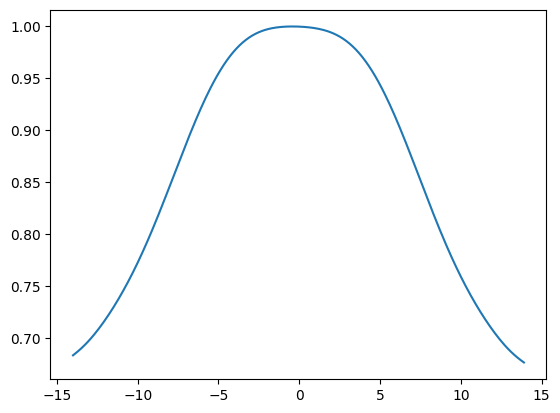

In [3]:
calib_dir = "C:\\Users\\Ralph Group\\Documents\\Github\\SagnacOperatingSys\\sagnac_control\\calibrations\\old_calibrations\\pre20260430\\"
field_correction_coeff= np.loadtxt(calib_dir + 'sagnac_fieldratio_calib.csv', delimiter=',')
field_correction_calib = np.poly1d(field_correction_coeff)
R1 = np.arange(-14, 14, 0.1)
plt.plot(R1, field_correction_calib(R1))
print(field_correction_coeff)

In [4]:
measured = pd.read_csv('2026-05-07/test_daedalus_radialPolar_calib_A090.0_2026-05-07_1.csv', comment = '#', index_col = 'theta')
ds = xr.Dataset(measured)
#ds = ds.where(ds.R < 16, drop=True)

[-1.15923691e-14 -9.46396477e-15  9.45445918e-12  6.68628403e-12
 -3.07071057e-09 -1.81182293e-09  4.86721604e-07  2.30338418e-07
 -3.12640285e-05 -1.19197176e-05 -1.48590055e-03 -2.19170288e-04
  9.99777265e-01]


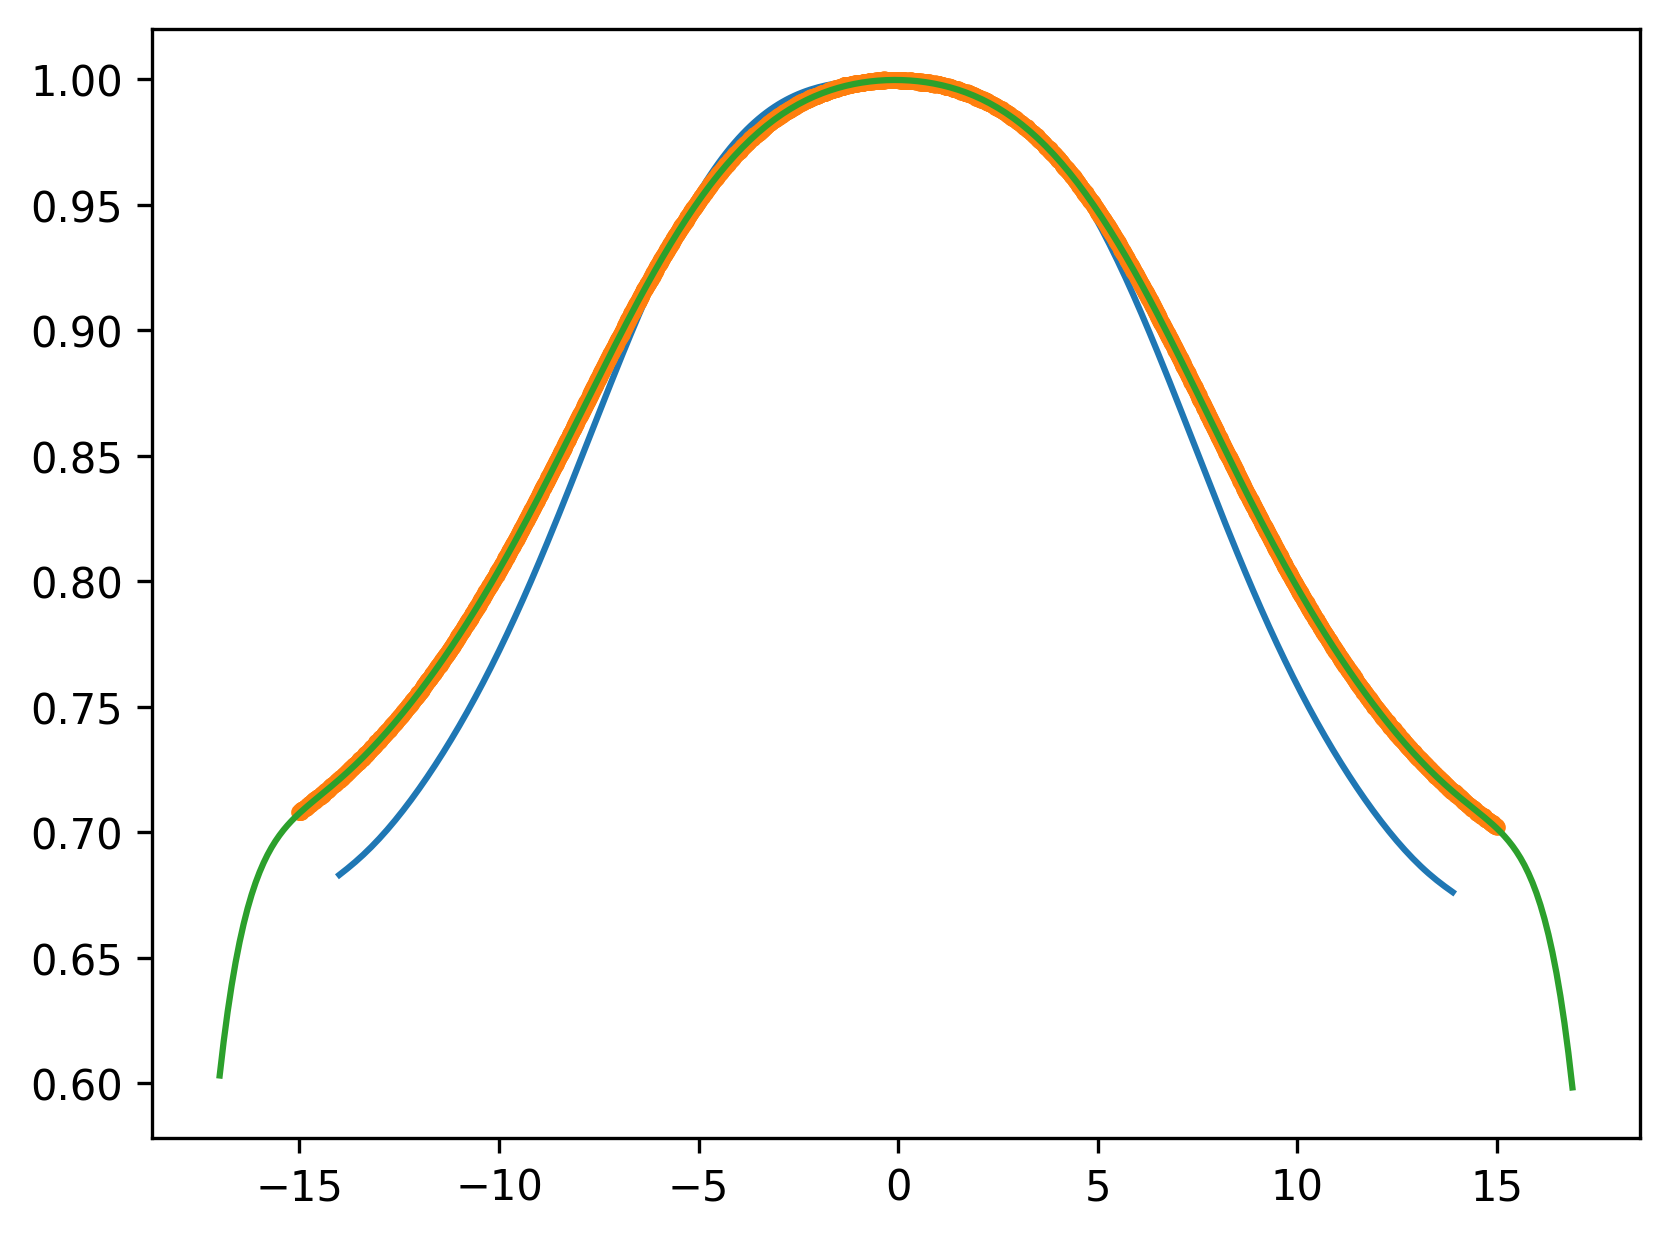

In [5]:
plt.figure(dpi=300)
plt.plot(R1, field_correction_calib(R1))
plt.plot(ds['R'], ds['B']/ds['B'].max(), '.')
R2=np.arange(-17,17,0.1)

field_correction_coeff_new = np.polyfit(ds['R'], ds['B']/ds['B'].max(), 12)
print(field_correction_coeff_new)
field_correction_calib_new = np.poly1d(field_correction_coeff_new)
plt.plot(R2, field_correction_calib_new(R2))
#save to fieldratio (field_correction)